# IMDb sentiment classification with a CNN

- This notebook trains a word-level convolutional classifier from scratch.
- The vocabulary is fitted on training reviews only. 
- Checkpoint selection uses validation accuracy;
- Test accuracy is measured once after training
- No pretrained weights or embeddings are used.

## 1. Configuration and hardware

In [1]:
import argparse
from collections import Counter
from dataclasses import asdict, dataclass
import html
import json
import os
from pathlib import Path
import platform
import random
import re
import socket
import subprocess
import tarfile
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset


DATASET_URL = "https://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz"


@dataclass
class Config:
    seed: int = 123
    vocab_size: int = 30_000
    min_frequency: int = 2
    max_length: int = 512
    embedding_dim: int = 200
    filter_widths: tuple = (3, 4, 5)
    filters_per_width: int = 128
    dropout: float = 0.5
    batch_size: int = 128
    learning_rate: float = 1e-3
    weight_decay: float = 1e-4
    max_epochs: int = 20
    patience: int = 3
    gradient_clip: float = 1.0


def setup(root, config):
    root = Path(root).resolve()
    (root / "artifacts").mkdir(parents=True, exist_ok=True)
    random.seed(config.seed)
    np.random.seed(config.seed)
    torch.manual_seed(config.seed)
    torch.cuda.manual_seed_all(config.seed)
    torch.set_num_threads(8)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True
    if not torch.cuda.is_available():
        raise RuntimeError("This experiment requires the Spark GPU; refusing a CPU fallback.")
    device = torch.device("cuda")
    environment = {
        "hostname": socket.gethostname(),
        "experiment_directory": str(root),
        "architecture": platform.machine(),
        "python": platform.python_version(),
        "pytorch": torch.__version__,
        "cuda": torch.version.cuda,
        "cudnn": torch.backends.cudnn.version(),
        "gpu": torch.cuda.get_device_name(0),
        "compute_capability": list(torch.cuda.get_device_capability(0)),
        "pandas": pd.__version__,
        "numpy": np.__version__,
        "precision": "bfloat16 autocast; float32 parameters and loss",
    }
    if not torch.cuda.is_bf16_supported():
        raise RuntimeError("This configuration requires bfloat16 support.")
    (root / "artifacts" / "config.json").write_text(json.dumps(asdict(config), indent=2) + "\n")
    (root / "artifacts" / "environment.json").write_text(json.dumps(environment, indent=2) + "\n")
    (root / "artifacts" / "training.log").write_text("")
    print(json.dumps(environment, indent=2))
    return root, device, environment

In [2]:
ROOT = Path('/home/rasbt/cnn-imdb')
config = Config()
root, device, environment = setup(ROOT, config)
print(json.dumps(asdict(config), indent=2))

{
  "hostname": "spark-e1bf",
  "experiment_directory": "/home/rasbt/cnn-imdb",
  "architecture": "aarch64",
  "python": "3.12.3",
  "pytorch": "2.13.0+cu130",
  "cuda": "13.0",
  "cudnn": 92000,
  "gpu": "NVIDIA GB10",
  "compute_capability": [
    12,
    1
  ],
  "pandas": "2.3.3",
  "numpy": "2.5.3",
  "precision": "bfloat16 autocast; float32 parameters and loss"
}
{
  "seed": 123,
  "vocab_size": 30000,
  "min_frequency": 2,
  "max_length": 512,
  "embedding_dim": 200,
  "filter_widths": [
    3,
    4,
    5
  ],
  "filters_per_width": 128,
  "dropout": 0.5,
  "batch_size": 128,
  "learning_rate": 0.001,
  "weight_decay": 0.0001,
  "max_epochs": 20,
  "patience": 3,
  "gradient_clip": 1.0
}


&nbsp;
## 2. Dataset split

Download the Stanford archive, shuffle the reviews, and split them into training, validation, and test sets. Check that review IDs are disjoint and count duplicate reviews across splits.

In [3]:
def prepare_data(root):

    data_dir = root / "data"
    data_dir.mkdir(exist_ok=True)
    archive = data_dir / "aclImdb_v1.tar.gz"
    if not archive.exists():
        partial = archive.with_suffix(".gz.partial")
        print("Downloading the Stanford IMDb archive on the Spark ...", flush=True)
        with requests.get(DATASET_URL, stream=True, timeout=(30, 120)) as response:
            response.raise_for_status()
            with partial.open("wb") as output:
                for chunk in response.iter_content(1024 * 1024):
                    output.write(chunk)
        partial.replace(archive)

    base = data_dir / "aclImdb"
    expected_dirs = [base / subset / label for subset in ("test", "train") for label in ("pos", "neg")]

    if any(len(list(path.glob("*.txt"))) != 12_500 for path in expected_dirs):
        with tarfile.open(archive, "r:gz") as tar:
            members = [m for m in tar.getmembers() if re.fullmatch(r"aclImdb/(test|train)/(pos|neg)/[0-9]+_[0-9]+\.txt", m.name)]
            assert len(members) == 50_000
            tar.extractall(data_dir, members=members, filter="data")
    rows = []
 
    for subset in ("test", "train"):
        for label, value in (("pos", 1), ("neg", 0)):
            for path in sorted((base / subset / label).glob("*.txt")):
                text = path.read_text(encoding="utf-8")
                rows.append({"text": text, "label": value, "review_id": str(path.relative_to(base))})
    assert len(rows) == 50_000

    frame = pd.DataFrame(rows).sample(frac=1, random_state=123).reset_index(drop=True)
    frame = frame.sample(frac=1, random_state=123).reset_index(drop=True)
    frames = {"train": frame.iloc[:35_000].copy(), "validation": frame.iloc[35_000:40_000].copy(),
              "test": frame.iloc[40_000:].copy()}
    assert frame.review_id.is_unique
 
    summary = {"split_method": "Combine official test/train reviews, then two pandas seed-123 shuffles; split 35000/5000/10000.",
               "splits": {}, "duplicate_text_overlap": {}}

    for name, split in frames.items():
        split[["text", "label"]].to_csv(data_dir / f"{name}.csv", index=False)
        summary["splits"][name] = {"reviews": len(split), "negative": int((split.label == 0).sum()),
                                   "positive": int((split.label == 1).sum())}
 
    for a, b in (("train", "validation"), ("train", "test"), ("validation", "test")):
        assert not set(frames[a].review_id) & set(frames[b].review_id)
        summary["duplicate_text_overlap"][f"{a}/{b}"] = len(set(frames[a].text) & set(frames[b].text))
    (root / "artifacts" / "data_summary.json").write_text(json.dumps(summary, indent=2) + "\n")
 
    print(pd.DataFrame(summary["splits"]).T[["reviews", "negative", "positive"]].to_string())
    print("Duplicate reviews across splits:", summary["duplicate_text_overlap"])
    return frames, summary

In [4]:
frames, data_summary = prepare_data(root)

           reviews negative positive
train        35000    17502    17498
validation    5000     2507     2493
test         10000     4991     5009
Duplicate reviews across splits: {'train/validation': 44, 'train/test': 119, 'validation/test': 28}


&nbsp;
## 3. Word tokens and vocabulary

- Strip HTML, lowercase, etc. 
- Keep at most 30,000 vocabulary entries including padding and unknown tokens.
- Use the first 512 tokens and fit the vocabulary on training text only.

In [5]:
def tokenize(text):
    text = re.sub(r"<[^>]+>", " ", html.unescape(text)).lower()
    return re.findall(r"[a-z0-9]+(?:'[a-z0-9]+)?", text)


def make_loaders(frames, root, config):
    tokenized = {name: [tokenize(text) for text in split.text] for name, split in frames.items()}
    counts = Counter(word for review in tokenized["train"] for word in review)
    words = sorted((word for word, count in counts.items() if count >= config.min_frequency),
                   key=lambda word: (-counts[word], word))[:config.vocab_size - 2]
    vocab = {"<pad>": 0, "<unk>": 1, **{word: i + 2 for i, word in enumerate(words)}}
    (root / "artifacts" / "vocabulary.json").write_text(json.dumps(vocab) + "\n")
    datasets, stats = {}, {}

    for name, reviews in tokenized.items():
        ids = torch.zeros((len(reviews), config.max_length), dtype=torch.long)
        lengths = torch.empty(len(reviews), dtype=torch.long)
        unknown = total = 0
        for i, review in enumerate(reviews):
            encoded = [vocab.get(word, 1) for word in review[:config.max_length]] or [1]
            ids[i, :len(encoded)] = torch.tensor(encoded)
            lengths[i] = len(encoded)
            unknown += encoded.count(1)
            total += len(encoded)
        labels = torch.tensor(frames[name].label.to_numpy(), dtype=torch.long)
        datasets[name] = TensorDataset(ids, lengths, labels)
        stats[name] = {"truncated_reviews": sum(len(review) > config.max_length for review in reviews),
                       "unknown_token_fraction": unknown / total}

    generator = torch.Generator().manual_seed(config.seed)
    train_loader = DataLoader(datasets["train"], batch_size=config.batch_size, shuffle=True,
                              generator=generator, num_workers=0, pin_memory=True, drop_last=False)
    eval_loaders = {name: DataLoader(dataset, batch_size=config.batch_size, shuffle=False,
                                    num_workers=0, pin_memory=True, drop_last=False)
                    for name, dataset in datasets.items()}

    info = {"vocabulary_size": len(vocab), "vocabulary_source": "training reviews only",
            "tokenizer": "HTML removal, lowercase, words/numbers with internal apostrophes; no subwords",
            "max_tokens": config.max_length, "statistics": stats}
    (root / "artifacts" / "tokenization.json").write_text(json.dumps(info, indent=2) + "\n")

    print(json.dumps(info, indent=2))

    return train_loader, eval_loaders, vocab

In [6]:
train_loader, eval_loaders, vocabulary = make_loaders(frames, root, config)

{
  "vocabulary_size": 30000,
  "vocabulary_source": "training reviews only",
  "tokenizer": "HTML removal, lowercase, words/numbers with internal apostrophes; no subwords",
  "max_tokens": 512,
  "statistics": {
    "train": {
      "truncated_reviews": 2553,
      "unknown_token_fraction": 0.01583798067292828
    },
    "validation": {
      "truncated_reviews": 382,
      "unknown_token_fraction": 0.018246098416049905
    },
    "test": {
      "truncated_reviews": 750,
      "unknown_token_fraction": 0.018387284495773638
    }
  }
}


&nbsp;
## 4. Text CNN

- Token IDs `[batch, 512]` become embeddings `[batch, 512, 200]`. 
- Convolution filters span 3, 4, or 5 tokens, each spanning all embedding dimensions.
- Each width produces 128 feature maps.
- ReLU and masked global max pooling reduce them to 384 features per review.
- Dropout and a linear layer produce two logits: negative (0) and positive (1).

In [7]:
class TextCNN(nn.Module):
    def __init__(self, vocabulary_size, config):
        super().__init__()
        self.embedding = nn.Embedding(vocabulary_size, config.embedding_dim, padding_idx=0)
        nn.init.uniform_(self.embedding.weight, -0.25, 0.25)
        with torch.no_grad():
            self.embedding.weight[0].zero_()
        self.convolutions = nn.ModuleList([
            nn.Conv1d(config.embedding_dim, config.filters_per_width, width)
            for width in config.filter_widths
        ])
        self.dropout = nn.Dropout(config.dropout)
        self.classifier = nn.Linear(len(config.filter_widths) * config.filters_per_width, 2)

    def forward(self, token_ids, lengths):
        embedded = self.embedding(token_ids).transpose(1, 2)
        pooled = []
        for convolution in self.convolutions:
            features = torch.relu(convolution(embedded))
            width = convolution.kernel_size[0]
            # Ignore windows that extend past the review. Very short reviews use
            # one zero-padded window so every filter has a well-defined output.
            valid_windows = (lengths - width + 1).clamp(min=1)
            positions = torch.arange(features.shape[-1], device=features.device)
            mask = positions[None, :] >= valid_windows[:, None]
            features = features.masked_fill(mask[:, None, :], torch.finfo(features.dtype).min)
            pooled.append(features.amax(dim=-1))
        return self.classifier(self.dropout(torch.cat(pooled, dim=1)))


def check_model(model, device):
    """Check that additional right padding does not change a review's prediction."""
    model.eval()
    sample = torch.tensor([[2, 3, 4, 5, 6], [3, 2, 0, 0, 0]], device=device)
    lengths = torch.tensor([5, 2], device=device)
    padded = nn.functional.pad(sample, (0, 7))

    with torch.no_grad():
        expected, actual = model(sample, lengths), model(padded, lengths)

    assert expected.shape == (2, 2) and torch.isfinite(actual).all()
    torch.testing.assert_close(actual, expected, rtol=1e-4, atol=1e-5)
    print("Passed: output shape, finite logits, and invariance to extra right padding.")

In [8]:
model = TextCNN(len(vocabulary), config).to(device)
print(model)
print(f'Parameters: {sum(p.numel() for p in model.parameters()):,}')
check_model(model, device)

TextCNN(
  (embedding): Embedding(30000, 200, padding_idx=0)
  (convolutions): ModuleList(
    (0): Conv1d(200, 128, kernel_size=(3,), stride=(1,))
    (1): Conv1d(200, 128, kernel_size=(4,), stride=(1,))
    (2): Conv1d(200, 128, kernel_size=(5,), stride=(1,))
  )
  (dropout): Dropout(p=0.5, inplace=False)
  (classifier): Linear(in_features=384, out_features=2, bias=True)
)
Parameters: 6,308,354


Passed: output shape, finite logits, and invariance to extra right padding.


&nbsp;
## 5. Train and select the checkpoint

- Train for at most 20 epochs, but stop after three epochs without improvement.
- Select the highest full-validation accuracy, break ties by validation loss.

In [9]:
@torch.inference_mode()
def evaluate(model, loader, device):
    model.eval()
    loss_sum = correct = examples = 0
    confusion = torch.zeros(2, 2, dtype=torch.long)
    for token_ids, lengths, labels in loader:
        token_ids, lengths, labels = (x.to(device, non_blocking=True) for x in (token_ids, lengths, labels))
        with torch.autocast("cuda", dtype=torch.bfloat16):
            logits = model(token_ids, lengths)
        loss_sum += nn.functional.cross_entropy(logits.float(), labels, reduction="sum").item()
        predictions = logits.argmax(dim=1)
        correct += (predictions == labels).sum().item()
        examples += labels.numel()
        confusion += torch.bincount((2 * labels + predictions).cpu(), minlength=4).reshape(2, 2)
    assert examples == len(loader.dataset)
    return {"accuracy": correct / examples, "correct": correct, "examples": examples,
            "loss": loss_sum / examples, "confusion_matrix": confusion.tolist()}


def train(model, train_loader, validation_loader, device, root, config):
    optimizer = torch.optim.AdamW(model.parameters(), lr=config.learning_rate, weight_decay=config.weight_decay)
    history, best_accuracy, best_loss, stale_epochs = [], -1.0, float("inf"), 0
    started = time.perf_counter()
    torch.cuda.reset_peak_memory_stats()

    for epoch in range(1, config.max_epochs + 1):
        epoch_start = time.perf_counter()
        model.train()
        loss_sum = correct = examples = 0

        for token_ids, lengths, labels in train_loader:
            token_ids, lengths, labels = (x.to(device, non_blocking=True) for x in (token_ids, lengths, labels))
            optimizer.zero_grad(set_to_none=True)
            with torch.autocast("cuda", dtype=torch.bfloat16):
                logits = model(token_ids, lengths)
            loss = nn.functional.cross_entropy(logits.float(), labels)
            if not torch.isfinite(loss):
                raise RuntimeError(f"Nonfinite loss in epoch {epoch}")
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), config.gradient_clip)
            optimizer.step()
            loss_sum += loss.item() * labels.numel()
            correct += (logits.argmax(dim=1) == labels).sum().item()
            examples += labels.numel()
        assert examples == len(train_loader.dataset)

        validation = evaluate(model, validation_loader, device)
        row = {"epoch": epoch, "train_loss_online": loss_sum / examples,
               "train_accuracy_online": correct / examples,
               "validation_loss": validation["loss"], "validation_accuracy": validation["accuracy"],
               "seconds": time.perf_counter() - epoch_start}
        history.append(row)
        improved = validation["accuracy"] > best_accuracy or (
            validation["accuracy"] == best_accuracy and validation["loss"] < best_loss)

        if improved:
            best_accuracy, best_loss, stale_epochs = validation["accuracy"], validation["loss"], 0
            torch.save({"model_state": model.state_dict(), "epoch": epoch, "config": asdict(config),
                        "validation_accuracy": best_accuracy}, root / "artifacts" / "best_model.pt")
        else:
            stale_epochs += 1

        pd.DataFrame(history).to_csv(root / "artifacts" / "history.csv", index=False)
        message = (f"Epoch {epoch:02d} | train loss {row['train_loss_online']:.4f} | "
                   f"online train acc {row['train_accuracy_online']:.2%} | "
                   f"validation acc {validation['accuracy']:.2%} | "
                   f"validation loss {validation['loss']:.4f} | {row['seconds']:.1f}s" +
                   (" | checkpoint saved" if improved else ""))
        print(message, flush=True)

        with (root / "artifacts" / "training.log").open("a") as output:
            output.write(message + "\n")
        if stale_epochs >= config.patience:
            print(f"Early stopping after {config.patience} epochs without validation improvement.")
            break

    training_seconds = time.perf_counter() - started
    checkpoint = torch.load(root / "artifacts" / "best_model.pt", map_location=device, weights_only=True)
    model.load_state_dict(checkpoint["model_state"])
    info = {"epochs_completed": len(history), "selected_epoch": checkpoint["epoch"],
            "training_seconds": training_seconds, "peak_cuda_memory_bytes": torch.cuda.max_memory_allocated(),
            "selection_rule": "Highest full-validation accuracy; lower validation loss breaks ties.",
            "early_stopping_patience": config.patience}
    (root / "artifacts" / "training_summary.json").write_text(json.dumps(info, indent=2) + "\n")
    print(f"Restored epoch {checkpoint['epoch']}; training took {training_seconds / 60:.2f} minutes.")
    return pd.DataFrame(history), info

In [10]:
history, training_info = train(model, train_loader, eval_loaders['validation'], device, root, config)

Epoch 01 | train loss 0.4896 | online train acc 75.01% | validation acc 87.34% | validation loss 0.3070 | 10.1s | checkpoint saved


Epoch 02 | train loss 0.2678 | online train acc 88.83% | validation acc 91.20% | validation loss 0.2304 | 10.4s | checkpoint saved


Epoch 03 | train loss 0.1694 | online train acc 93.59% | validation acc 91.16% | validation loss 0.2283 | 10.5s


Epoch 04 | train loss 0.0896 | online train acc 96.99% | validation acc 90.70% | validation loss 0.2630 | 10.4s


Epoch 05 | train loss 0.0438 | online train acc 98.77% | validation acc 90.44% | validation loss 0.3095 | 10.5s


Early stopping after 3 epochs without validation improvement.
Restored epoch 2; training took 0.87 minutes.


&nbsp;
## 6. Evaluate results

In [11]:
def save_results(model, eval_loaders, device, root, config, environment, data_summary, training_info):
    # This is the only test evaluation. Training and checkpoint selection use validation only.
    results = {name: evaluate(model, loader, device) for name, loader in eval_loaders.items()}
    metrics = {"model": "TextCNN, trained from scratch", "config": asdict(config),
               "environment": environment, "training": training_info, "data": data_summary,
               "parameters": sum(p.numel() for p in model.parameters()), "splits": results}
    (root / "artifacts" / "metrics.json").write_text(json.dumps(metrics, indent=2) + "\n")
    table = pd.DataFrame({name: {"accuracy_percent": 100 * result["accuracy"], "correct": result["correct"],
                                 "reviews": result["examples"], "cross_entropy": result["loss"]}
                          for name, result in results.items()}).T
    print("Full-split evaluation of the selected checkpoint (dropout disabled):")
    print(table.to_string(float_format=lambda value: f"{value:.4f}"))
    lines = ["# IMDb CNN results", "",
             "| Split | Reviews | Correct | Accuracy |", "|---|---:|---:|---:|"]
    for name, result in results.items():
        lines.append(f"| {name.title()} | {result['examples']:,} | {result['correct']:,} | {result['accuracy']:.2%} |")
    for section, values in (("Configuration", asdict(config)),
                            ("Training", training_info),
                            ("Environment", environment),
                            ("Data", data_summary)):
        lines.extend(["", f"## {section}", "", "```json", json.dumps(values, indent=2), "```"])
    lines.append("")
    (root / "artifacts" / "README.md").write_text("\n".join(lines))
    return metrics, table


def plot_history(history, root):
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.5), constrained_layout=True)
    axes[0].plot(history.epoch, history.train_loss_online, label="Training (online)", color="#336699")
    axes[0].plot(history.epoch, history.validation_loss, label="Validation", color="#d48234")
    axes[0].set(xlabel="Epoch", ylabel="Cross-entropy loss")
    axes[1].plot(history.epoch, history.train_accuracy_online * 100, label="Training (online)", color="#336699")
    axes[1].plot(history.epoch, history.validation_accuracy * 100, label="Validation", color="#d48234")
    axes[1].set(xlabel="Epoch", ylabel="Accuracy (%)", ylim=(50, 100))
    for ax in axes:
        ax.spines[["top", "right"]].set_visible(False)
        ax.legend(frameon=False)
    fig.savefig(root / "artifacts" / "learning_curves.png", dpi=160)
    plt.show()

In [12]:
metrics, results_table = save_results(model, eval_loaders, device, root, config, environment, data_summary, training_info)
results_table

Full-split evaluation of the selected checkpoint (dropout disabled):
            accuracy_percent    correct    reviews  cross_entropy
train                95.5429 33440.0000 35000.0000         0.1414
validation           91.2000  4560.0000  5000.0000         0.2304
test                 90.0700  9007.0000 10000.0000         0.2368


,accuracy_percent,correct,reviews,cross_entropy
train,95.542857,33440.0,35000.0,0.141428
validation,91.200000,4560.0,5000.0,0.230424
test,90.070000,9007.0,10000.0,0.236750


&nbsp;
## 7. Learning curves and test confusion matrix

Training curves show the online metric; validation uses evaluation mode. The headline metrics above use the selected checkpoint for all three splits.

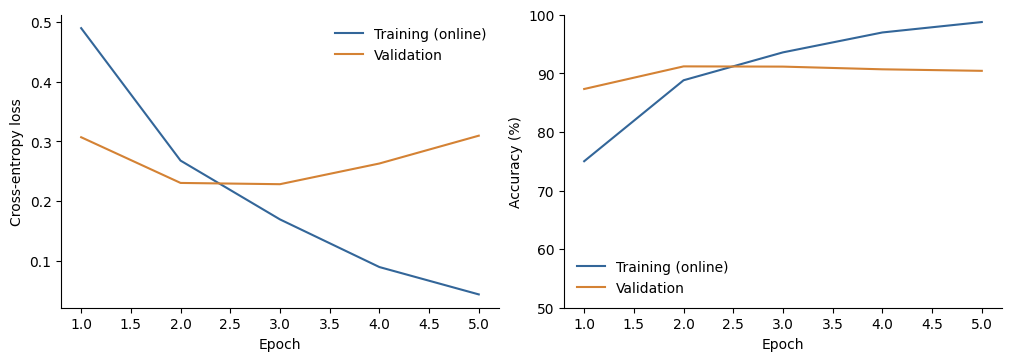

,Predicted negative,Predicted positive
Actual negative,4440,551
Actual positive,442,4567


In [13]:
plot_history(history, root)
confusion = pd.DataFrame(metrics['splits']['test']['confusion_matrix'], index=['Actual negative', 'Actual positive'], columns=['Predicted negative', 'Predicted positive'])
confusion